<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kelima/blob/main/Praktikum_5_4_MG_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


PRAKTIKUM 5.4: ADAPTIVE DAN HYBRID FILTERING


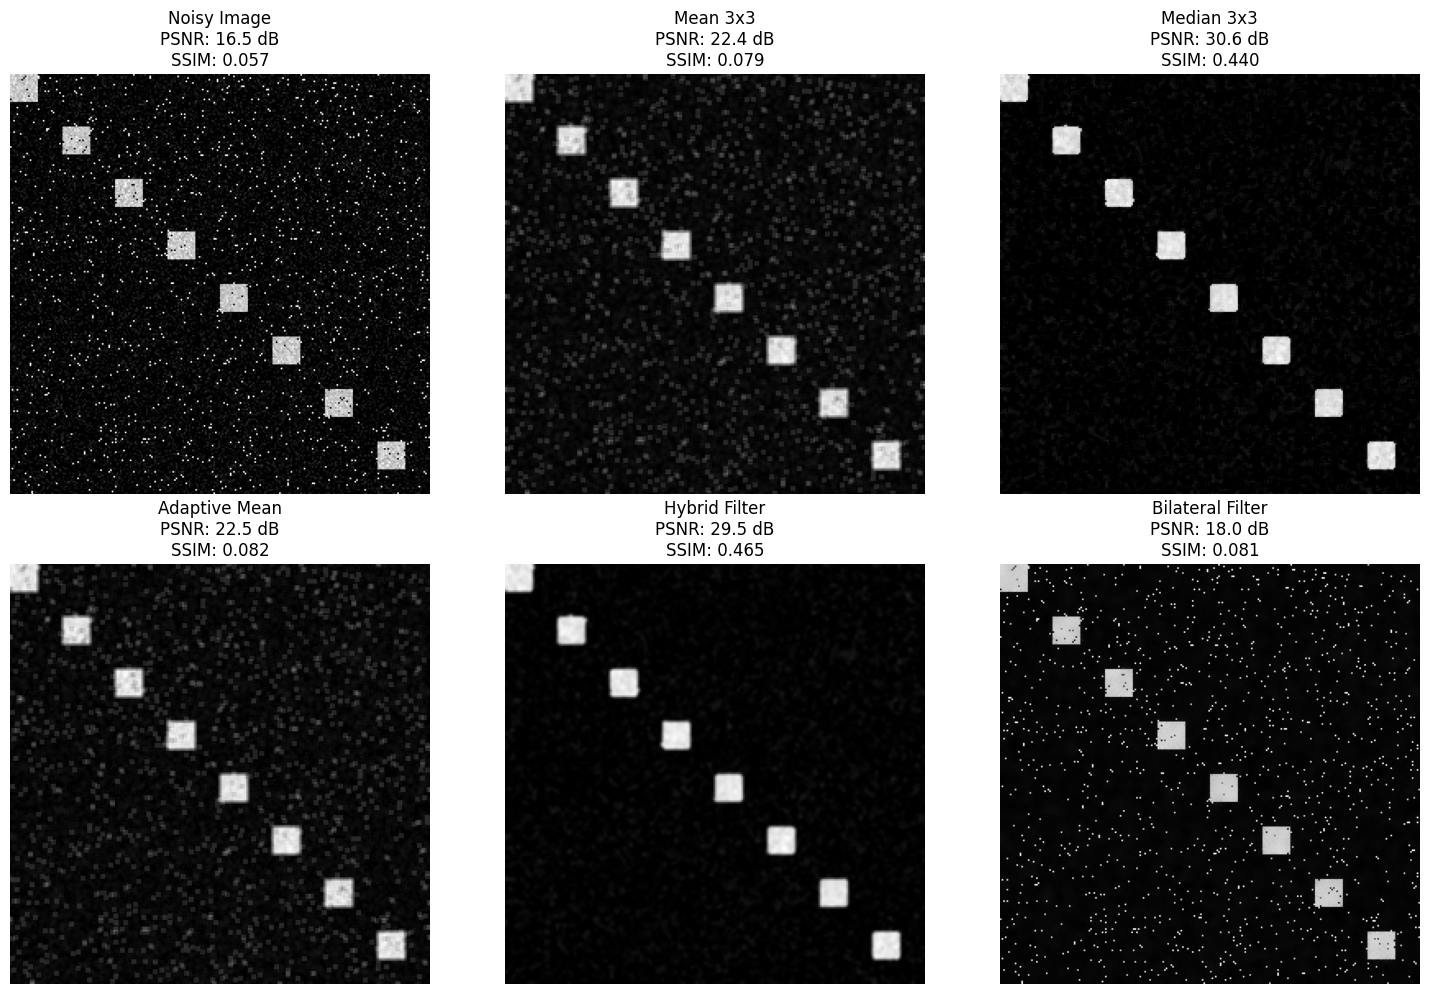


ADVANCED FILTERS PERFORMANCE COMPARISON
--------------------------------------------------------------------------------
Filter               MSE          PSNR (dB)    SSIM        
--------------------------------------------------------------------------------
Noisy Image          1464.58      16.47        0.057       
Mean 3x3             370.47       22.44        0.079       
Median 3x3           56.56        30.61        0.440       
Adaptive Mean        361.48       22.55        0.082       
Hybrid Filter        73.02        29.50        0.465       
Bilateral Filter     1026.69      18.02        0.081       


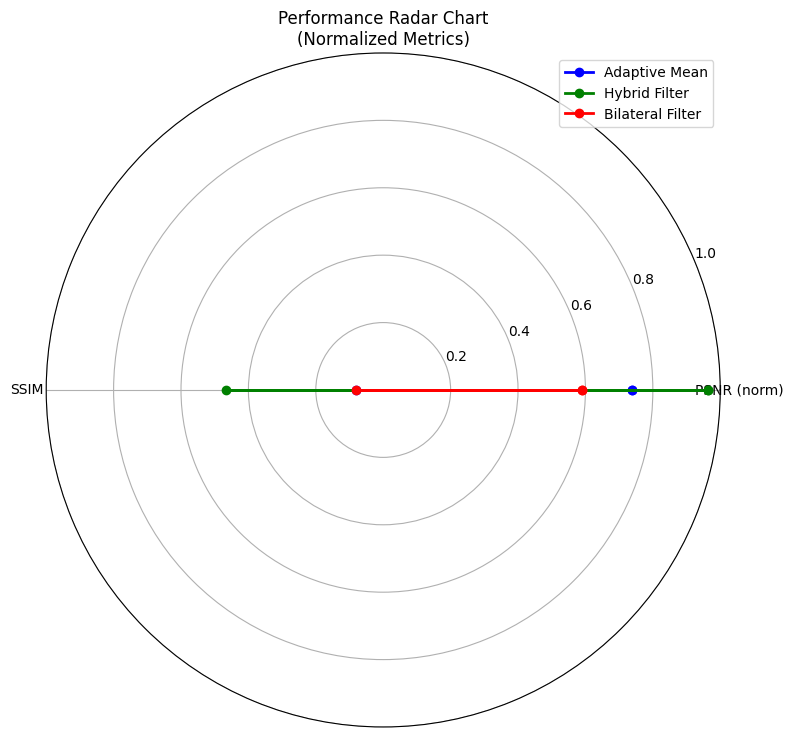

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def adaptive_hybrid_filters():
    """
    Demonstrasi adaptive dan hybrid filtering approaches
    """
    print("\nPRAKTIKUM 5.4: ADAPTIVE DAN HYBRID FILTERING")
    print("=" * 50)

    # Create test image with mixed noise
    clean_img = np.zeros((256, 256), dtype=np.uint8)

    # Create pattern
    for i in range(0, 256, 32):
        cv2.rectangle(clean_img, (i, i), (i+16, i+16), 200, -1)

    # Add mixed noise (Gaussian + Salt-and-Pepper)
    noisy_img = clean_img.copy().astype(float)

    # Gaussian noise
    gaussian_noise = np.random.normal(0, 20, clean_img.shape)
    noisy_img += gaussian_noise

    # Salt-and-pepper noise
    salt_pepper = np.random.random(clean_img.shape)
    noisy_img[salt_pepper < 0.02] = 255  # Salt
    noisy_img[salt_pepper > 0.98] = 0    # Pepper

    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

    # Define custom filters
    def adaptive_mean_filter(image, window_size=3, threshold=30):
        """
        Adaptive mean filter based on local variance
        """
        h, w = image.shape
        output = image.copy().astype(float)

        pad = window_size // 2
        padded = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REFLECT)

        for i in range(h):
            for j in range(w):
                window = padded[i:i+window_size, j:j+window_size]
                local_mean = np.mean(window)
                local_var = np.var(window)

                # Apply filter only if variance is high (likely noise)
                if local_var > threshold:
                    output[i, j] = local_mean

        return np.clip(output, 0, 255).astype(np.uint8)

    def hybrid_filter(image):
        """
        Hybrid filter: median followed by Gaussian
        """
        # First pass: median for salt-and-pepper
        median_filtered = cv2.medianBlur(image, 3)
        # Second pass: Gaussian for Gaussian noise
        gaussian_filtered = cv2.GaussianBlur(median_filtered, (3, 3), 0)
        return gaussian_filtered

    def bilateral_filter_custom(image, d=9, sigma_color=75, sigma_space=75):
        """
        Bilateral filter (edge-preserving smoothing)
        """
        return cv2.bilateralFilter(image, d, sigma_color, sigma_space)

    # Apply different advanced filters
    filters = {
        'Noisy Image': lambda x: x,
        'Mean 3x3': lambda x: cv2.blur(x, (3, 3)),
        'Median 3x3': lambda x: cv2.medianBlur(x, 3),
        'Adaptive Mean': lambda x: adaptive_mean_filter(x, 3, 30),
        'Hybrid Filter': lambda x: hybrid_filter(x),
        'Bilateral Filter': lambda x: bilateral_filter_custom(x)
    }

    # Apply and evaluate
    results = []

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()

    for idx, (filter_name, filter_func) in enumerate(filters.items()):
        filtered_img = filter_func(noisy_img)

        # Calculate multiple metrics
        mse = np.mean((clean_img.astype(float) - filtered_img.astype(float)) ** 2)
        psnr = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

        # SSIM (simplified)
        def calculate_ssim(img1, img2):
            C1 = (0.01 * 255) ** 2
            C2 = (0.03 * 255) ** 2

            mu1 = cv2.GaussianBlur(img1.astype(float), (11, 11), 1.5)
            mu2 = cv2.GaussianBlur(img2.astype(float), (11, 11), 1.5)

            mu1_sq = mu1 ** 2
            mu2_sq = mu2 ** 2
            mu1_mu2 = mu1 * mu2

            sigma1_sq = cv2.GaussianBlur(img1.astype(float) ** 2, (11, 11), 1.5) - mu1_sq
            sigma2_sq = cv2.GaussianBlur(img2.astype(float) ** 2, (11, 11), 1.5) - mu2_sq
            sigma12 = cv2.GaussianBlur(img1.astype(float) * img2.astype(float), (11, 11), 1.5) - mu1_mu2

            ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
            return np.mean(ssim_map)

        ssim = calculate_ssim(clean_img, filtered_img)

        results.append({
            'filter': filter_name,
            'mse': mse,
            'psnr': psnr,
            'ssim': ssim
        })

        # Display
        axes[idx].imshow(filtered_img, cmap='gray')
        axes[idx].set_title(f'{filter_name}\nPSNR: {psnr:.1f} dB\nSSIM: {ssim:.3f}')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

    # Performance comparison table
    print("\nADVANCED FILTERS PERFORMANCE COMPARISON")
    print("-" * 80)
    print(f"{'Filter':<20} {'MSE':<12} {'PSNR (dB)':<12} {'SSIM':<12}")
    print("-" * 80)

    for result in results:
        print(f"{result['filter']:<20} {result['mse']:<12.2f} {result['psnr']:<12.2f} {result['ssim']:<12.3f}")

    # Radar chart comparison
    from matplotlib.patches import Circle

    # Normalize metrics for radar chart
    metrics = ['PSNR', 'SSIM']

    # Invert MSE (higher is worse, so we use 1/MSE)
    mse_values = [r['mse'] for r in results]
    max_mse = max(mse_values)
    inv_mse = [1 - (mse / max_mse) for mse in mse_values]

    psnr_values = [r['psnr'] for r in results]
    max_psnr = max(psnr_values)
    norm_psnr = [psnr / max_psnr for psnr in psnr_values]

    ssim_values = [r['ssim'] for r in results]
    norm_ssim = ssim_values  # SSIM already 0-1

    # Select top filters for radar chart
    top_filters = ['Adaptive Mean', 'Hybrid Filter', 'Bilateral Filter']
    top_indices = [list(filters.keys()).index(f) for f in top_filters]

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]  # Close the polygon

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    colors = ['blue', 'green', 'red']

    for idx, filter_idx in enumerate(top_indices):
        values = [norm_psnr[filter_idx], ssim_values[filter_idx]]
        values += values[:1]  # Close the polygon

        ax.plot(angles, values, 'o-', linewidth=2, label=top_filters[idx], color=colors[idx])
        ax.fill(angles, values, alpha=0.1, color=colors[idx])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['PSNR (norm)', 'SSIM'])
    ax.set_ylim(0, 1)
    ax.set_title('Performance Radar Chart\n(Normalized Metrics)')
    ax.legend(loc='upper right')
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    return results

advanced_filter_results = adaptive_hybrid_filters()